In [11]:
import geopandas as gpd
import osmnx as ox
import network_functions as nf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

from collections import Counter, defaultdict
from itertools import pairwise 
from shapely.geometry import Polygon, LineString, Point

C:\Users\manpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\networkx\utils\backends.py:94: RuntimeWarning: networkx backend defined more than once: nx_loopback
  backends = _get_backends("networkx.backends")


In [12]:
link_data_gdf = gpd.read_file("replica-itc_2025-11_04_25-network_link_layer.geojson")
traffic_data = pd.read_parquet("replica-itc_2025-10_28_25-trips_dataset.parquet")
car_trips = traffic_data[traffic_data['primary_mode'].str.contains('auto')]

In [13]:
### Area of Interest for Project Prompt ###
# this is copy & pasted from Lat-Lon format in Google Maps
top_left = (38.543680985703226, -121.7440795432951)
top_right = (38.545050789861584, -121.73714115854816)
bottom_right = (38.54333958192836, -121.73654298866767)
bottom_left = (38.54217103842081, -121.74365700939322)

def ll_to_xy(ll):
    return (ll[1], ll[0])  # (lat,lon) -> (lon,lat)

aoi_poly_wgs84 = Polygon([
    ll_to_xy(top_left),
    ll_to_xy(top_right),
    ll_to_xy(bottom_right),
    ll_to_xy(bottom_left),
    ll_to_xy(top_left),
])

aoi = gpd.GeoDataFrame(geometry=[aoi_poly_wgs84], crs="EPSG:4326")
aoi.to_crs(link_data_gdf.crs, inplace=True)
aoi['geometry'] = aoi['geometry'].buffer(0.0005)
aoi = aoi.to_crs(link_data_gdf.crs)


C:\Users\manpa\AppData\Local\Temp\ipykernel_27880\620008124.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  aoi['geometry'] = aoi['geometry'].buffer(0.0005)


In [14]:
location = "Davis, California, USA"
poly = ox.geocode_to_gdf(location)
G = ox.graph_from_place(location, network_type="drive")

In [15]:
origin_nodes = ox.nearest_nodes(
    G, car_trips["origin_bgrp_lng_2020"], car_trips["origin_bgrp_lat_2020"]
)
destination_nodes = ox.nearest_nodes(
    G, car_trips["destination_bgrp_lng_2020"], car_trips["destination_bgrp_lat_2020"]
)

dists, paths = nf.path_dijkstra(
    origins=origin_nodes,
    destinations=destination_nodes, #type: ignore
    G=G,
    # dist_param="travel_time",
    origins_in_nodes=True,
    destinations_in_nodes=True,
    pairs=True,
    verbose=True,
)

od_counts = Counter(zip(origin_nodes, destination_nodes))

edges = defaultdict(int)
for (origin, destination), path in paths.items():
    k = od_counts.get((origin, destination), 1)
    for u, v in pairwise(path):
        edges[(u, v)] += k

edge = ox.graph_to_gdfs(G, nodes=False, edges=True)
edge_reset = edge.reset_index()

# vectorized (no row-wise apply)
edge_reset["uv"] = list(zip(edge_reset["u"], edge_reset["v"]))
edge_reset["usage"] = edge_reset["uv"].map(edges).fillna(0).astype(int)

edge_with_usage = edge_reset.drop(columns=["uv"]).set_index(["u", "v", "key"])

edges_df = edge_with_usage.assign(use_bin=np.log1p(edge_with_usage["usage"]) // 1)


pairs chosen
sources made. length 49


100%|██████████| 49/49 [00:00<00:00, 363.49it/s]


<Figure size 1200x800 with 0 Axes>

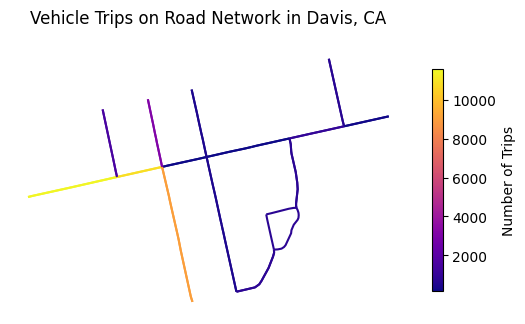

In [16]:
edges_in_davis=edges_df.sjoin(aoi, how="inner", predicate="intersects")
edges_in_davis_nonzero = edges_in_davis[edges_in_davis["usage"] > 0]
plt.figure(figsize=(12, 8))
edges_in_davis_nonzero.plot(column="usage", cmap="plasma", legend=True
                            , legend_kwds={'label': "Number of Trips", 'shrink': 0.6})
plt.title("Vehicle Trips on Road Network in Davis, CA")

plt.axis("off")
plt.show()